# Задание

Используя набор данных <a href='https://www.kaggle.com/unsdsn/world-happiness?select=2017.csv'>World Happiness Report 2017</a> визуализировать:
1. Топ-5 стран с наивысшими рейтингами по каждому континенту, расположив их на одном мультиокне;
2. График зависимости уровня свободы от уровня счастья, указав на графике отклонения при помощи box whisker chart;
3. Облако точек зависимости уровня "счастья" от уровня ВВП страны;
4. Распределение по столбцу Family для различных значений уровня "счастья";
5. Добавить в набор данных столбец с указанием экономического мира страны ("первый мир", "второй мир" и "третий мир") и визуализировать топ-5 стран с наивысшим рейтингом "счастья" для каждого из миров.


### 1. Топ-5 стран с наивысшими рейтингами по каждому континенту, расположив их на одном мультиокне;

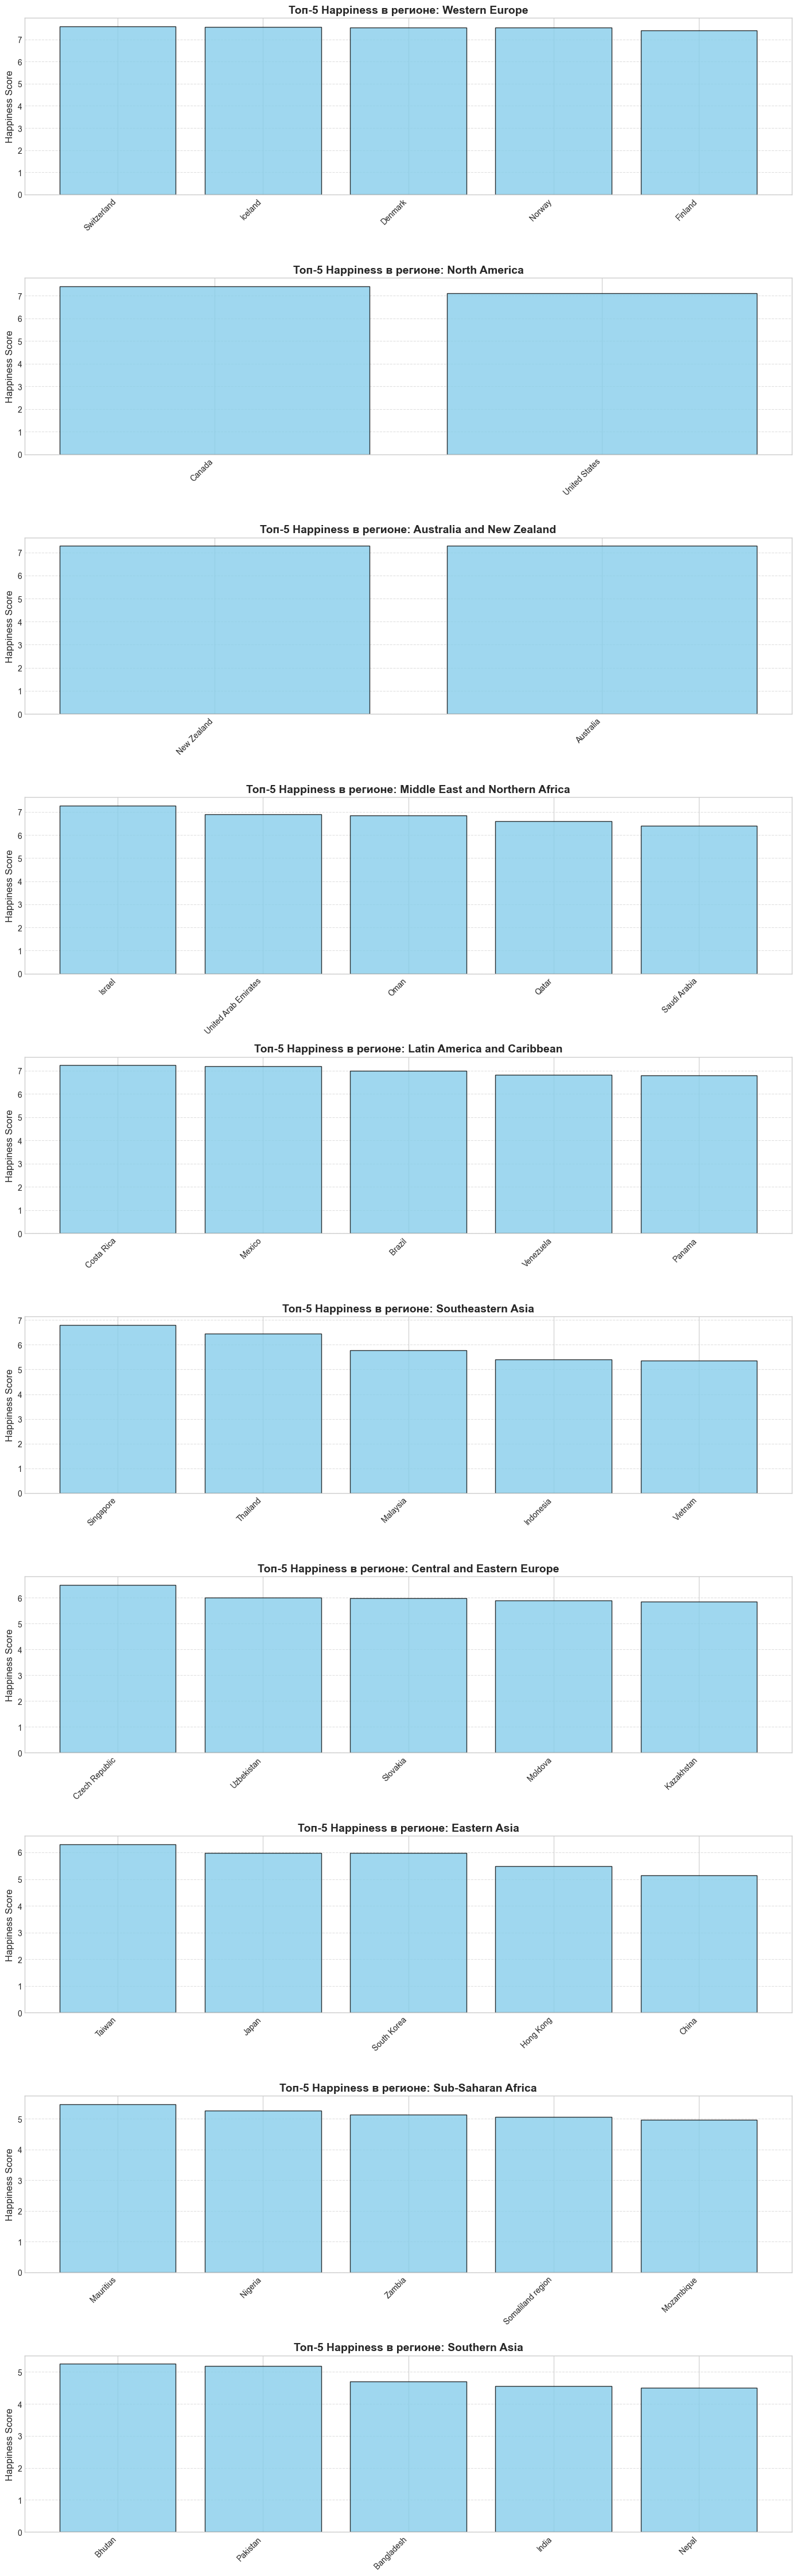

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 10

df = pd.read_csv('2015.csv')

df.columns = [col.strip() for col in df.columns]

regions = df['Region'].unique()

fig, axes = plt.subplots(len(regions), 1, figsize=(14, 4.5 * len(regions)))
axes = np.atleast_1d(axes)

for i, region in enumerate(regions):
    ax = axes[i]
    region_data = df[df['Region'] == region].sort_values('Happiness Score', ascending=False).head(5)
    
    ax.bar(region_data['Country'], region_data['Happiness Score'], color='skyblue', edgecolor='black', alpha=0.8)
    ax.set_title(f'Топ-5 Happiness в регионе: {region}', fontweight='bold')
    ax.set_xticklabels(region_data['Country'], rotation=45, ha='right')
    ax.set_ylabel('Happiness Score')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 2. График зависимости уровня свободы от уровня счастья, указав на графике отклонения при помощи box whisker chart;


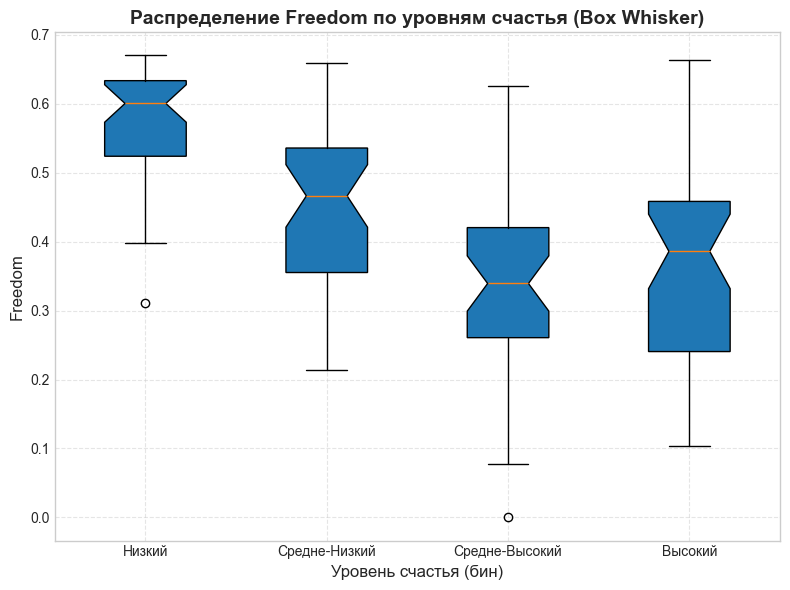

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

df['Happiness_Bin'] = pd.qcut(df['Happiness Score'], q=4, labels=['Низкий', 'Средне-Низкий', 'Средне-Высокий', 'Высокий'])
box_data = [df[df['Happiness_Bin'] == b]['Freedom'].values for b in df['Happiness_Bin'].unique()]

bp = ax.boxplot(box_data, labels=['Низкий', 'Средне-Низкий', 'Средне-Высокий', 'Высокий'],
                 patch_artist=True, notch=True, showfliers=True)

ax.set_title('Распределение Freedom по уровням счастья (Box Whisker)', fontweight='bold')
ax.set_xlabel('Уровень счастья (бин)')
ax.set_ylabel('Freedom')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 3. Облако точек зависимости уровня "счастья" от уровня ВВП страны;


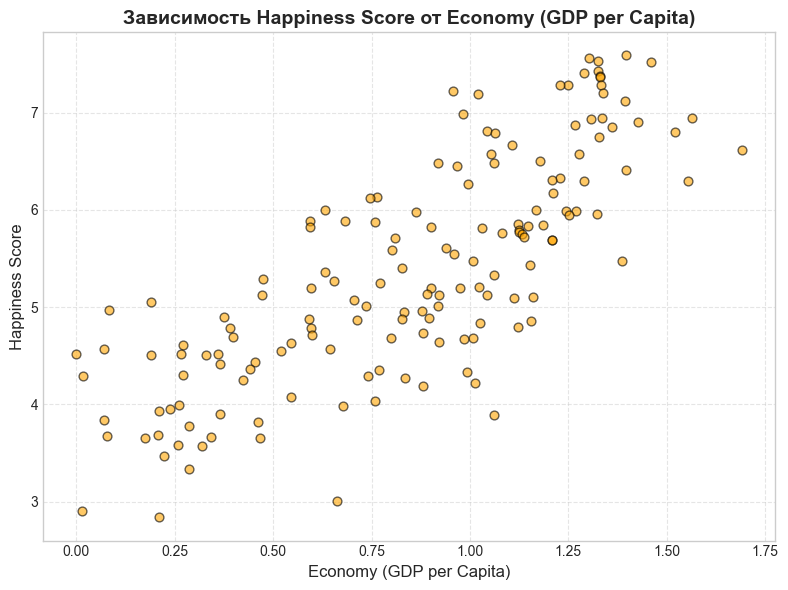

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['Economy (GDP per Capita)'], df['Happiness Score'], c='orange', edgecolor='black', alpha=0.6, s=40)
ax.set_title('Зависимость Happiness Score от Economy (GDP per Capita)', fontweight='bold')
ax.set_xlabel('Economy (GDP per Capita)')
ax.set_ylabel('Happiness Score')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 4. Распределение по столбцу Family для различных значений уровня "счастья";


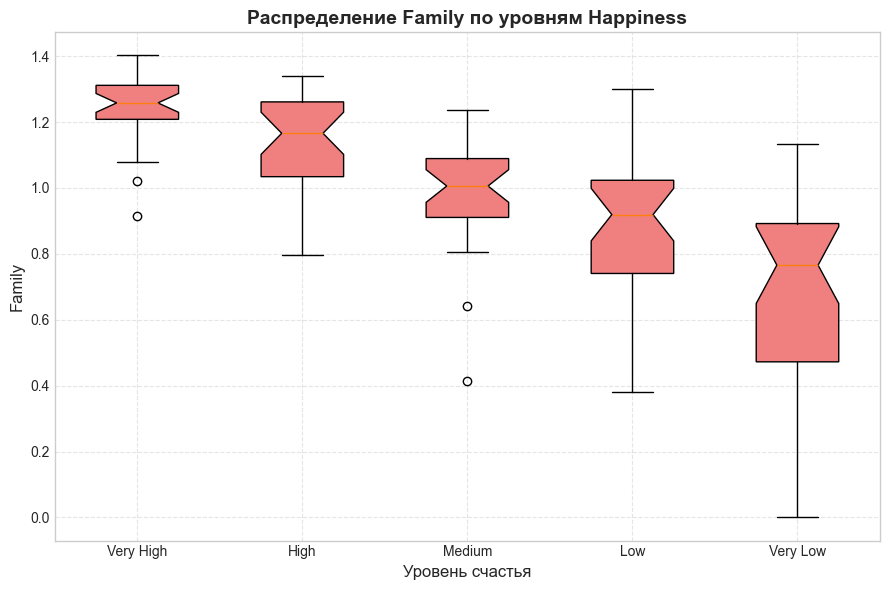

In [12]:
df['Happiness_Group'] = pd.qcut(df['Happiness Score'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

fig, ax = plt.subplots(figsize=(9, 6))
family_data = [df[df['Happiness_Group'] == g]['Family'].values for g in df['Happiness_Group'].unique()]

bp = ax.boxplot(family_data, labels=df['Happiness_Group'].unique(), patch_artist=True, notch=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
    
ax.set_title('Распределение Family по уровням Happiness', fontweight='bold')
ax.set_xlabel('Уровень счастья')
ax.set_ylabel('Family')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 5. Добавить в набор данных столбец с указанием экономического мира страны ("первый мир", "второй мир" и "третий мир") и визуализировать топ-5 стран с наивысшим рейтингом "счастья" для каждого из миров.


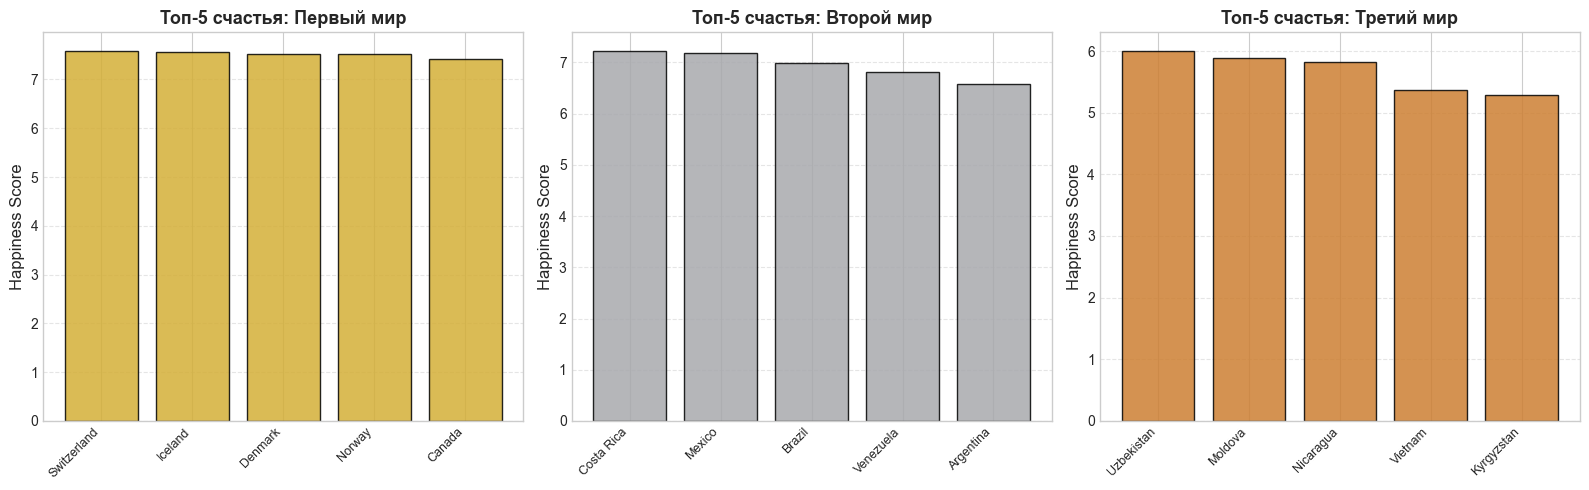

In [15]:
df['Economic_World'] = pd.qcut(df['Economy (GDP per Capita)'],
                               q=[0, 0.33, 0.66, 1],
                               labels=['Третий мир', 'Второй мир', 'Первый мир'])

top5_world = df.sort_values('Happiness Score', ascending=False).groupby('Economic_World').head(5).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#d4af37', '#a8a9ad', '#cd7f32']

for i, world in enumerate(['Первый мир', 'Второй мир', 'Третий мир']):
    ax = axes[i]
    data = top5_world[top5_world['Economic_World'] == world]
    
    ax.bar(data['Country'], data['Happiness Score'], color=colors[i], edgecolor='black', alpha=0.85)
    ax.set_title(f'Топ-5 счастья: {world}', fontweight='bold', fontsize=13)
    ax.set_xticklabels(data['Country'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Happiness Score')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()